<a href="https://colab.research.google.com/github/Sarath-I/Generative-Adversarial-Network/blob/main/Generative_Adversarial_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI and GenAI Assignment**

## **Generative Adversarial Network**

### **Objective:**
To implement and train a simple Generative Adversarial Network (GAN) using TensorFlow
(Keras API) to generate handwritten digit images that resemble the MNIST dataset.
This mini-assignment aims to strengthen your understanding of adversarial learning and
generative modeling.

In [1]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# Load MNIST dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize to [-1, 1]
x_train = (x_train - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1).astype("float32")

BUFFER_SIZE = 60000
BATCH_SIZE = 256

# Dataset pipeline
dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)

In [3]:
# Generator Model
def build_generator():
    model = tf.keras.Sequential()

    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))

    model.add(layers.Conv2DTranspose(128, 5, strides=1,
                                     padding="same",
                                     use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, 5, strides=2,
                                     padding="same",
                                     use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, 5, strides=2,
                                     padding="same",
                                     use_bias=False,
                                     activation="tanh"))
    return model

In [4]:
# Discriminator Model
def build_discriminator():
    model = tf.keras.Sequential()

    model.add(layers.Conv2D(64, 5, strides=2,
                            padding="same",
                            input_shape=[28,28,1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, 5, strides=2,
                            padding="same"))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation="sigmoid"))
    return model

In [5]:
# Create Models
generator = build_generator()
discriminator = build_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Loss Functions
cross_entropy = tf.keras.losses.BinaryCrossentropy()

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

In [7]:
# Optimizer
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

In [8]:
# Training
EPOCHS = 20
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])

gen_loss_history = []
disc_loss_history = []

In [9]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_gradients = gen_tape.gradient(
        gen_loss, generator.trainable_variables
    )
    disc_gradients = disc_tape.gradient(
        disc_loss, discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(gen_gradients, generator.trainable_variables)
    )
    discriminator_optimizer.apply_gradients(
        zip(disc_gradients, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

In [10]:
# Save generated images
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4,4))

    for i in range(predictions.shape[0]):
        plt.subplot(4,4,i+1)
        plt.imshow(predictions[i,:,:,0]*127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Epoch {epoch}")
    plt.show()

In [11]:
def train(dataset, epochs):
    for epoch in range(epochs):
        epoch_gen_loss = []
        epoch_disc_loss = []

        for step, image_batch in enumerate(dataset):
            gen_loss, disc_loss = train_step(image_batch)

            epoch_gen_loss.append(gen_loss)
            epoch_disc_loss.append(disc_loss)

            # Verbose: print every 50 batches
            if step % 50 == 0:
                print(f"Epoch {epoch+1}, Step {step}, "
                      f"G_loss={gen_loss:.4f}, "
                      f"D_loss={disc_loss:.4f}")

        gen_loss_history.append(
            tf.reduce_mean(epoch_gen_loss).numpy()
        )
        disc_loss_history.append(
            tf.reduce_mean(epoch_disc_loss).numpy()
        )

        print(f"Epoch {epoch+1} Summary: "
              f"G_loss={gen_loss_history[-1]:.4f}, "
              f"D_loss={disc_loss_history[-1]:.4f}")

        # NEW: display generated images every 5 epochs
        if (epoch + 1) % 5 == 0:
            generate_and_save_images(generator, epoch + 1, seed)


Epoch 1, Step 0, G_loss=0.6942, D_loss=1.3946
Epoch 1, Step 50, G_loss=0.6066, D_loss=1.3596
Epoch 1, Step 100, G_loss=0.6818, D_loss=1.2807
Epoch 1, Step 150, G_loss=0.6951, D_loss=1.3313
Epoch 1, Step 200, G_loss=0.6653, D_loss=1.4172
Epoch 1 Summary: G_loss=0.6485, D_loss=1.3396
Epoch 2, Step 0, G_loss=0.7696, D_loss=1.2623
Epoch 2, Step 50, G_loss=0.7662, D_loss=1.3311
Epoch 2, Step 100, G_loss=0.7608, D_loss=1.2391
Epoch 2, Step 150, G_loss=0.7421, D_loss=1.4352
Epoch 2, Step 200, G_loss=0.7250, D_loss=1.3239
Epoch 2 Summary: G_loss=0.7217, D_loss=1.3545
Epoch 3, Step 0, G_loss=0.7210, D_loss=1.2955
Epoch 3, Step 50, G_loss=0.8048, D_loss=1.2747
Epoch 3, Step 100, G_loss=0.8932, D_loss=1.2668
Epoch 3, Step 150, G_loss=0.6667, D_loss=1.4430
Epoch 3, Step 200, G_loss=0.7160, D_loss=1.3671
Epoch 3 Summary: G_loss=0.7316, D_loss=1.3512
Epoch 4, Step 0, G_loss=0.6681, D_loss=1.4740
Epoch 4, Step 50, G_loss=0.7617, D_loss=1.2354
Epoch 4, Step 100, G_loss=0.6856, D_loss=1.3066
Epoch 4, S

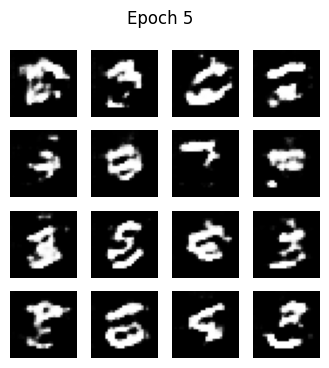

Epoch 6, Step 0, G_loss=0.8272, D_loss=1.3139
Epoch 6, Step 50, G_loss=0.9728, D_loss=1.0686
Epoch 6, Step 100, G_loss=0.8798, D_loss=1.2521
Epoch 6, Step 150, G_loss=0.8641, D_loss=1.2505
Epoch 6, Step 200, G_loss=0.8275, D_loss=1.3310
Epoch 6 Summary: G_loss=0.8333, D_loss=1.2598
Epoch 7, Step 0, G_loss=0.4614, D_loss=1.4023
Epoch 7, Step 50, G_loss=0.8064, D_loss=1.3026
Epoch 7, Step 100, G_loss=0.8095, D_loss=1.2183
Epoch 7, Step 150, G_loss=0.8735, D_loss=1.1581
Epoch 7, Step 200, G_loss=0.9239, D_loss=1.1573
Epoch 7 Summary: G_loss=0.8524, D_loss=1.2507
Epoch 8, Step 0, G_loss=0.8045, D_loss=1.3195
Epoch 8, Step 50, G_loss=0.4847, D_loss=1.4334
Epoch 8, Step 100, G_loss=0.8455, D_loss=1.1808
Epoch 8, Step 150, G_loss=0.8380, D_loss=1.2502
Epoch 8, Step 200, G_loss=0.8628, D_loss=1.2872
Epoch 8 Summary: G_loss=0.8184, D_loss=1.2855
Epoch 9, Step 0, G_loss=0.7908, D_loss=1.2896
Epoch 9, Step 50, G_loss=0.7026, D_loss=1.2887
Epoch 9, Step 100, G_loss=0.6671, D_loss=1.3327
Epoch 9, S

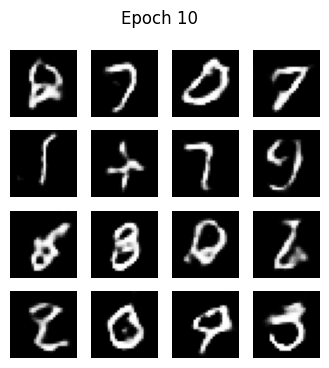

Epoch 11, Step 0, G_loss=0.7702, D_loss=1.3434
Epoch 11, Step 50, G_loss=0.7038, D_loss=1.3362
Epoch 11, Step 100, G_loss=0.7737, D_loss=1.5377
Epoch 11, Step 150, G_loss=0.8711, D_loss=1.1835
Epoch 11, Step 200, G_loss=0.8669, D_loss=1.3915
Epoch 11 Summary: G_loss=0.7903, D_loss=1.3230
Epoch 12, Step 0, G_loss=0.6555, D_loss=1.3725
Epoch 12, Step 50, G_loss=0.6743, D_loss=1.2980
Epoch 12, Step 100, G_loss=0.8015, D_loss=1.3420
Epoch 12, Step 150, G_loss=0.7208, D_loss=1.3502
Epoch 12, Step 200, G_loss=0.8705, D_loss=1.2949
Epoch 12 Summary: G_loss=0.7657, D_loss=1.3309
Epoch 13, Step 0, G_loss=0.7810, D_loss=1.4193
Epoch 13, Step 50, G_loss=0.7369, D_loss=1.4180
Epoch 13, Step 100, G_loss=0.6836, D_loss=1.3941
Epoch 13, Step 150, G_loss=0.6928, D_loss=1.3617
Epoch 13, Step 200, G_loss=0.8055, D_loss=1.2258
Epoch 13 Summary: G_loss=0.7913, D_loss=1.3186
Epoch 14, Step 0, G_loss=0.7932, D_loss=1.2543
Epoch 14, Step 50, G_loss=0.6757, D_loss=1.3696
Epoch 14, Step 100, G_loss=0.7698, D_l

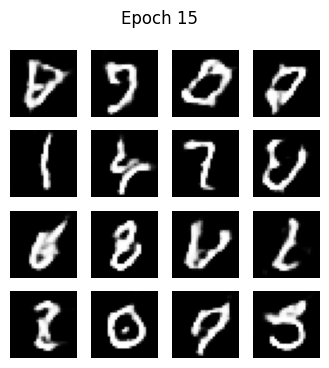

Epoch 16, Step 0, G_loss=0.6754, D_loss=1.3044
Epoch 16, Step 50, G_loss=0.7266, D_loss=1.3492
Epoch 16, Step 100, G_loss=0.8093, D_loss=1.3062
Epoch 16, Step 150, G_loss=0.8301, D_loss=1.1958
Epoch 16, Step 200, G_loss=0.7763, D_loss=1.4201
Epoch 16 Summary: G_loss=0.7880, D_loss=1.3184
Epoch 17, Step 0, G_loss=0.7799, D_loss=1.3167
Epoch 17, Step 50, G_loss=0.8638, D_loss=1.3779
Epoch 17, Step 100, G_loss=0.6916, D_loss=1.3407
Epoch 17, Step 150, G_loss=0.7362, D_loss=1.3368
Epoch 17, Step 200, G_loss=0.8139, D_loss=1.3171
Epoch 17 Summary: G_loss=0.7814, D_loss=1.3172
Epoch 18, Step 0, G_loss=0.7528, D_loss=1.3246
Epoch 18, Step 50, G_loss=0.6397, D_loss=1.3178
Epoch 18, Step 100, G_loss=0.8100, D_loss=1.2449
Epoch 18, Step 150, G_loss=0.5506, D_loss=1.3764
Epoch 18, Step 200, G_loss=0.7221, D_loss=1.2023
Epoch 18 Summary: G_loss=0.7894, D_loss=1.3178
Epoch 19, Step 0, G_loss=0.8149, D_loss=1.3345
Epoch 19, Step 50, G_loss=0.8220, D_loss=1.3352
Epoch 19, Step 100, G_loss=0.7895, D_l

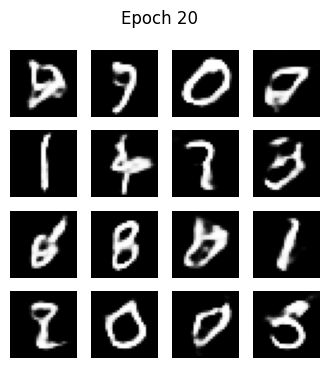

In [12]:
# Start training
train(dataset, EPOCHS)

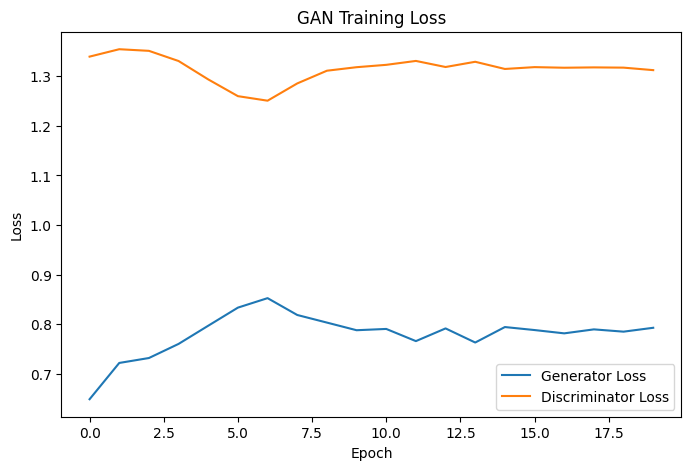

In [13]:
plt.figure(figsize=(8,5))
plt.plot(gen_loss_history, label="Generator Loss")
plt.plot(disc_loss_history, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.show()